In [12]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np

import sys
from pathlib import Path
sys.path.insert(0, str(Path("../../scripts").resolve()))
import graph_export
import paths

Precalculate token counts by source per language.
Only by inspecting filenames and file sizes; contents are never read.

In [ ]:
# Precalculate token counts by source per language.
# We only inspect filenames and file sizes; contents are never read.
from pathlib import Path

RAW_DIR = paths.exist("data/0_raw", 3)
IGNORE_PATH = paths.edit("results/1_process/1_filter/ignored_files.csv", 3)
STATS_PATH = paths.edit("results/1_process/3_truncate/statistics.csv", 3)
SHORTCUTS_PATH = paths.edit("src/1_process/0_download/leipzig/lepzig_shortcuts.csv", 3)

SOURCE_MARKERS = {
    "_bible": "Bible",
    "-ud": "UD",
    "_glot500_": "Glot500",
}
LEIPZIG_SOURCE_NAMES = {
    "wikipedia": "Wikipedia",
    "news": "News",
    "newscrawl": "Newscrawl",
    "community": "Community",
    "web": "Web",
    "mixed": "Mixed",
}


def source_from_name(path: Path) -> str:
    stem = path.stem
    for marker, source in SOURCE_MARKERS.items():
        if marker in stem:
            return source

    parts = stem.split("_", 2)
    return LEIPZIG_SOURCE_NAMES.get(parts[1], "Other") if len(parts) > 1 else "Other"


ignored = set(pd.read_csv(IGNORE_PATH)["filename"])
file_rows = [
    {
        "lang": path.stem.split("-")[0][:3],
        "source": source_from_name(path),
        "bytes": path.stat().st_size,
    }
    for path in RAW_DIR.glob("*.csv")
    if path.name not in ignored
]

size_by_source = pd.DataFrame(file_rows).pivot_table(
    index="lang",
    columns="source",
    values="bytes",
    aggfunc="sum",
    fill_value=0,
)
all_sources = sorted(size_by_source.columns)

# Scale each language's source byte shares to the already computed token total.
totals = pd.read_csv(STATS_PATH).set_index("file")["total_frequency"]
names = pd.read_csv(SHORTCUTS_PATH).set_index("code")["language"]

df_sources = size_by_source.join(totals.rename("total"), how="inner")
source_share = df_sources[all_sources].div(df_sources[all_sources].sum(axis=1), axis=0)
df_sources[all_sources] = source_share.mul(df_sources["total"], axis=0).round().astype(int)

df_sources.insert(0, "name", [names.get(lang, lang) for lang in df_sources.index])
df_sources = df_sources.reset_index().rename(columns={"index": "lang"})

extra_cols = [source for source in ["Bible", "UD", "Glot500", "TIL"] if source in df_sources.columns]
df_sources["extra"] = df_sources[extra_cols].sum(axis=1)
df_sources["existing"] = df_sources["total"] - df_sources["extra"]
df_sources["ratio"] = np.where(
    df_sources["existing"] > 0,
    df_sources["total"] / df_sources["existing"],
    np.nan,
)

print(f"Loaded {len(df_sources)} languages, {len(all_sources)} source categories: {', '.join(all_sources)}")
print(f"Total tokens across all sources: {df_sources['total'].sum():,.0f}")
for source in all_sources:
    token_count = df_sources[source].sum()
    percentage = token_count / df_sources["total"].sum() * 100
    print(f"  {source:12s}: {token_count:>15,} tokens  ({percentage:5.2f}%)")

Loaded 442 languages, 10 source categories: Bible, Community, Glot500, Mixed, News, Newscrawl, Other, UD, Web, Wikipedia
Total tokens across all sources: 94,228,165,066
  Bible       :      87,100,164 tokens  ( 0.09%)
  Community   :     509,117,376 tokens  ( 0.54%)
  Glot500     :  29,187,827,788 tokens  (30.98%)
  Mixed       :   5,543,581,313 tokens  ( 5.88%)
  News        :  25,633,399,393 tokens  (27.20%)
  Newscrawl   :   4,570,235,349 tokens  ( 4.85%)
  Other       :  11,524,351,649 tokens  (12.23%)
  UD          :     201,850,357 tokens  ( 0.21%)
  Web         :  11,072,185,645 tokens  (11.75%)
  Wikipedia   :   5,898,516,018 tokens  ( 6.26%)


graph_export: saved data_sources.png


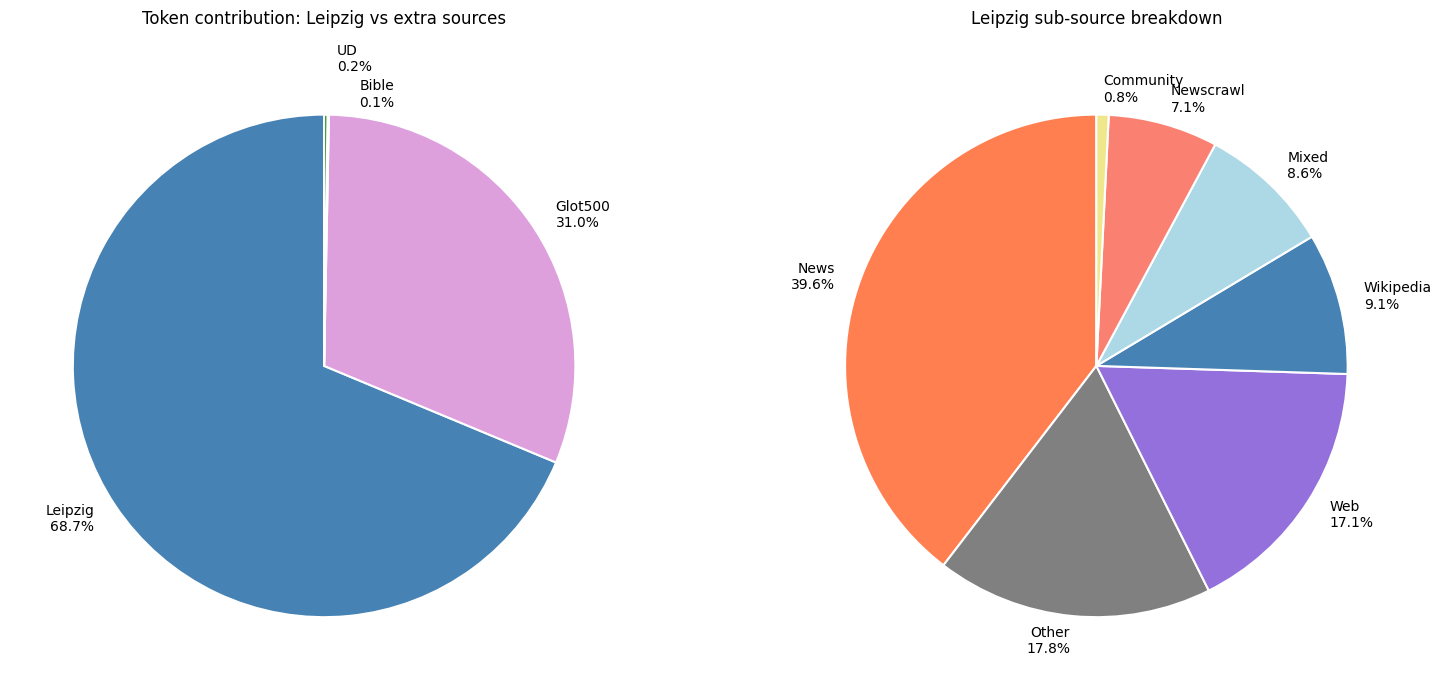

In [ ]:
EXTRA_SOURCES = ["Glot500", "Bible", "UD"]
EXTRA = set(EXTRA_SOURCES)
LEIPZIG_SOURCES = [source for source in all_sources if source not in EXTRA]

SOURCE_COLORS = {
    "Leipzig": "steelblue",
    "Glot500": "plum",
    "Bible": "goldenrod",
    "UD": "forestgreen",
    "News": "coral",
    "Newscrawl": "salmon",
    "Web": "mediumpurple",
    "Wikipedia": "steelblue",
    "Mixed": "lightblue",
    "Community": "khaki",
    "Other": "gray",
}


def source_total(source):
    return df_sources[source].sum() if source in df_sources else 0


def labels_with_percent(labels, sizes):
    total = sum(sizes)
    return [f"{label}\n{size / total * 100:.1f}%" for label, size in zip(labels, sizes)]


def draw_left_pie(ax):
    labels = ["Leipzig"] + [source for source in EXTRA_SOURCES if source_total(source) > 0]
    sizes = [sum(source_total(source) for source in LEIPZIG_SOURCES)] + [source_total(source) for source in labels[1:]]
    colors = [SOURCE_COLORS[label] for label in labels]

    wedges, texts = ax.pie(
        sizes,
        labels=labels_with_percent(labels, sizes),
        colors=colors,
        startangle=90,
        wedgeprops=dict(edgecolor="white", linewidth=1.5),
    )

    for text in texts:
        text.set_fontsize(10)
        if text.get_text().startswith("UD"):
            text.set_position((0.05, 1.22))
            text.set_ha("left")
        elif text.get_text().startswith("Bible"):
            text.set_position((0.14, 1.08))
            text.set_ha("left")

    ax.set_title("Token contribution: Leipzig vs extra sources", pad=20)


def draw_right_pie(ax):
    labels = sorted(LEIPZIG_SOURCES, key=source_total, reverse=True)
    labels = [source for source in labels if source_total(source) > 0]
    sizes = [source_total(source) for source in labels]
    colors = [SOURCE_COLORS.get(label, "gray") for label in labels]

    wedges, texts = ax.pie(
        sizes,
        labels=labels_with_percent(labels, sizes),
        colors=colors,
        startangle=90,
        wedgeprops=dict(edgecolor="white", linewidth=1.5),
    )

    for text in texts:
        text.set_fontsize(10)

    ax.set_title("Leipzig sub-source breakdown", pad=20)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
draw_left_pie(ax1)
draw_right_pie(ax2)

plt.tight_layout()
graph_export.save("data_sources", fig)
plt.show()

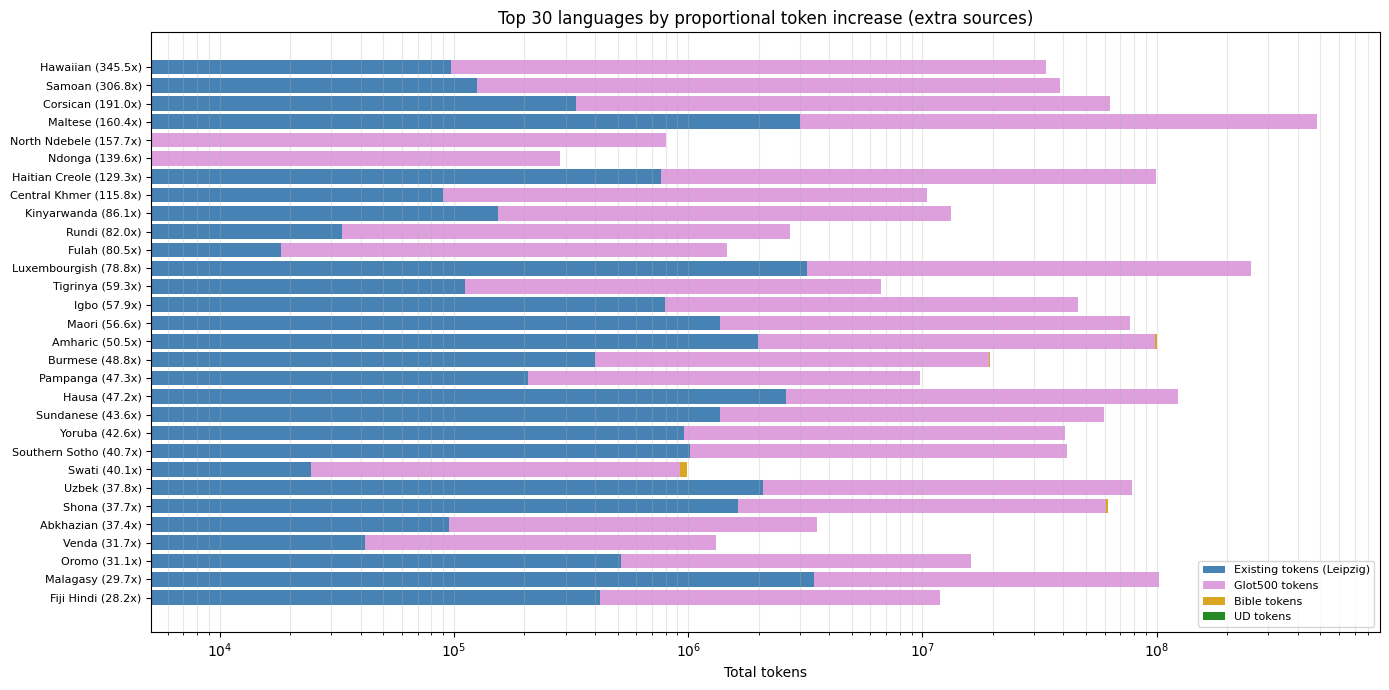

Languages with Bible   data:  65  (     87,100,164 tokens)
Languages with UD      data:  91  (    201,850,357 tokens)
Languages with Glot500 data: 387  ( 29,187,827,788 tokens)

Top 10 by proportional raise:
 Lang  Name                          Existing    Glot500      Bible         UD        After   Ratio
  haw  Hawaiian                        97,332 33,534,467          0          0   33,631,799 345.54x
  smo  Samoan                         125,823 38,471,658          0          0   38,597,481 306.76x
  cos  Corsican                       332,305 63,130,515          0          0   63,462,820 190.98x
  mlt  Maltese                      3,014,205 480,355,158          0     83,409  483,452,772 160.39x
  nde  North Ndebele                    5,113    800,961          0          0      806,074 157.65x
  ndo  Ndonga                           2,028    281,143          0          0      283,171 139.63x
  hat  Haitian Creole                 768,683 98,596,282          0     59,128   99,424,093

In [ ]:

# Bar chart: top 30 languages by proportional token increase

df_extra = df_sources[df_sources["extra"] > 0].copy()
df_extra = df_extra[df_extra["existing"] > 0].sort_values("ratio", ascending=False)
TOP_N = 30
df_top = df_extra.head(TOP_N).copy()

fig, ax = plt.subplots(figsize=(14, 7))

y_pos = np.arange(len(df_top))
ax.barh(y_pos, df_top["existing"], color="steelblue", label="Existing tokens (Leipzig)")

left = df_top["existing"].values.copy()
for src, color in [("Glot500", "plum"), ("Bible", "goldenrod"), ("UD", "forestgreen"), ("TIL", "darkorange")]:
    if src in df_top.columns:
        vals = df_top[src].values
        ax.barh(y_pos, vals, left=left, color=color, label=f"{src} tokens")
        left = left + vals

ax.set_yticks(y_pos)
ax.set_yticklabels([f"{row['name']} ({row.ratio:.1f}x)" for _, row in df_top.iterrows()], fontsize=8)
ax.invert_yaxis()
ax.set_xscale("log")
ax.set_xlabel("Total tokens")
ax.set_title(f"Top {TOP_N} languages by proportional token increase (extra sources)")
ax.legend(fontsize=8, loc="lower right")
ax.grid(True, axis="x", alpha=0.3, which="both")
plt.tight_layout()
plt.show()

# Print summary
for src in extra_cols:
    n = (df_sources[src] > 0).sum()
    total = df_sources[src].sum()
    print(f"Languages with {src:7s} data: {n:3d}  ({total:>15,} tokens)")
print(f"\nTop 10 by proportional raise:")
print(f"{'Lang':>5}  {'Name':<25} {'Existing':>12} {'Glot500':>10} {'Bible':>10} {'UD':>10} {'After':>12} {'Ratio':>7}")
for _, r in df_top.head(10).iterrows():
    print(f"{r.lang:>5}  {r['name']:<25} {r.existing:>12,.0f} {r.get('Glot500',0):>10,.0f} {r.get('Bible',0):>10,.0f} {r.get('UD',0):>10,.0f} {r.total:>12,.0f} {r.ratio:>6.2f}x")